# ML-отчёт: АВТ → гидроочистка → блендинг → оптимизация

Историческая точность оценивается только на отложенном test. Последствия действий и резервуары — отдельные **модельные сценарии**, не доказательство причинного эффекта. Метрики не подменяются синтетическими результатами.


## Методика и подготовка

Train: 2023–2024; validation: январь–июнь 2025; test: июль 2025–7 августа 2026. Hydro выбирает полное окно или 2024 по validation MAE серы. LightGBM: q10/q50/q90, сырой интервал — 80%. Conformal 90% калибруется на validation; для серы bias и интервал дополнительно адаптируются по прошлым доступным ПАК. Значение в T обновляет историю только после собственного прогноза. Будущие измерения и недоступные ЛИМС не используются.

ЛИМС датируется отбором пробы, но становится доступен модели только через 4 часа. `label__*` хранит факт для оценки и никогда не передаётся в публичный `predict`. Сера обучается на сыром ПАК; лаборатория точки 2 показана отдельно как контрольный источник.

Перед Run All из корня проекта:
```sh
PYTHONPATH=backend .venv/bin/python -m ml.training.preflight
PYTHONPATH=backend .venv/bin/python -m ml.training.train_all
```
Либо `make train` в уже запущенном Docker Compose. Используйте ядро с зависимостями backend, IPython и matplotlib. Отсутствующие артефакты остановят расчёт с явным сообщением, а не дадут вымышленные результаты.


In [16]:
from __future__ import annotations

import json
import logging
import sys
import time
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Контрастная палитра, одинаковая для всех графиков отчёта.
PALETTE = {
    "ink": "#14213D",
    "blue": "#0066FF",
    "cyan": "#00A6D6",
    "orange": "#FF7A00",
    "red": "#D90429",
    "green": "#00875A",
    "purple": "#7B2CBF",
    "gray": "#64748B",
    "grid": "#CBD5E1",
    "paper": "#FFFFFF",
}

plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 130,
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor": PALETTE["paper"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.labelcolor": PALETTE["ink"],
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "axes.titlepad": 12,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "text.color": PALETTE["ink"],
    "xtick.color": PALETTE["ink"],
    "ytick.color": PALETTE["ink"],
    "grid.color": PALETTE["grid"],
    "grid.alpha": 0.45,
    "grid.linewidth": 0.7,
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.edgecolor": PALETTE["grid"],
    "legend.framealpha": 0.96,
})
pd.set_option("display.max_colwidth", 100)
logging.getLogger("optuna").setLevel(logging.WARNING)


def find_project_root(start: Path | None = None) -> Path:
    # Работает и при запуске из корня, и из папки notebooks/.
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "backend" / "ml").is_dir() and (candidate / "docs").is_dir():
            return candidate
    raise RuntimeError("Не найден корень проекта neftecode")


PROJECT_ROOT = find_project_root()
BACKEND_DIR = PROJECT_ROOT / "backend"
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

from ml.models.blending import BlendingModel
from ml.models.quality_avt import TARGET_CONFIG as AVT_TARGET_CONFIG, QualityAVTModel
from ml.models.quality_hydro import TARGET_CONFIG as HYDRO_TARGET_CONFIG, QualityHydroModel
from ml.optimizer.pareto import ParetoOptimizer
from ml.validation.walk_forward import (
    TEST_END_EXCLUSIVE,
    TEST_START,
    VALIDATION_START,
    _batch_prediction_arrays,
    _fresh_label_mask,
    _physical_target_mask,
    split_by_time,
)

ARTIFACT_DIR = BACKEND_DIR / "ml" / "artifacts"
FEATURES_PATH = PROJECT_ROOT / "data" / "ml_training.parquet"
METRICS_PATH = ARTIFACT_DIR / "metrics_report.json"
AVT_MODEL_PATH = ARTIFACT_DIR / "quality_avt.pkl"
HYDRO_MODEL_PATH = ARTIFACT_DIR / "quality_hydro.pkl"

print(f"Project root: {PROJECT_ROOT}")
from ml.availability import inference_frame, AVAILABILITY_MARKER
from ml.reporting import prediction_observations, acceptance_table
from ml.scenario_blending import default_scenario
from ml.models.anomaly import AnomalyDetector
from ml.types import Component
from ml.vak import VAKCatalog
from ml.demo_scenarios import clean_json


Project root: /Users/pavelatrusev/projects/neftecode


In [17]:
# Читаем справочники и структуру без переобучения и без записи в data layer.
catalog = VAKCatalog.load_expert()
print("Источник: expert_xlsx_2026_09_17; число формул:", len(catalog.names))
print("Управление Hydro: hydro_T6 (температура), hydro_F9 (массовый расход), hydro_P13 (давление)")
print("Управляемость этих трёх тегов необходимо подтвердить у эксперта.")
structure_paths = [
    "backend/ml/types.py", "backend/ml/models/quality_avt.py",
    "backend/ml/models/quality_hydro.py", "backend/ml/models/blending.py",
    "backend/ml/models/anomaly.py", "backend/ml/optimizer/pareto.py",
    "backend/ml/training/train_all.py", "backend/ml/validation/walk_forward.py",
    "backend/data_layer/feature_registry.yaml", "docs/api_ml.md",
]
display(pd.DataFrame({"path": structure_paths,
                      "exists": [(PROJECT_ROOT / p).exists() for p in structure_paths]}))
print("CFPP АВТ: в train нет лабораторных меток; cetane_number: мало меток.")
print("Проверка качества и критериев приёмки ниже требует новых обученных артефактов.")


Источник: expert_xlsx_2026_09_17; число формул: 17
Управление Hydro: hydro_T6 (температура), hydro_F9 (массовый расход), hydro_P13 (давление)
Управляемость этих трёх тегов необходимо подтвердить у эксперта.


,path,exists
0,backend/ml/types.py,True
1,backend/ml/models/quality_avt.py,True
2,backend/ml/models/quality_hydro.py,True
3,backend/ml/models/blending.py,True
4,backend/ml/models/anomaly.py,True
5,backend/ml/optimizer/pareto.py,True
6,backend/ml/training/train_all.py,True
7,backend/ml/validation/walk_forward.py,True
8,backend/data_layer/feature_registry.yaml,True
9,docs/api_ml.md,True


CFPP АВТ: в train нет лабораторных меток; cetane_number: мало меток.
Проверка качества и критериев приёмки ниже требует новых обученных артефактов.


## Загрузка новых артефактов и факта

Для оценки используем `ml_training.parquet`: доступные на момент T признаки плюс отдельно сохранённые лабораторные метки. Из среза для API все `label__*` удаляются. Старые артефакты и кеш без политики задержки не подходят.


In [18]:
required_paths = [FEATURES_PATH, METRICS_PATH, AVT_MODEL_PATH, HYDRO_MODEL_PATH]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    missing = "\n".join(f"- {path.relative_to(PROJECT_ROOT)}" for path in missing_paths)
    raise FileNotFoundError(f"Не найдены артефакты:\n{missing}\nЗапустите `make train` из корня проекта.")

with METRICS_PATH.open(encoding="utf-8") as file:
    metrics_report = json.load(file)

quality_avt = QualityAVTModel.load(str(AVT_MODEL_PATH))
quality_hydro = QualityHydroModel.load(str(HYDRO_MODEL_PATH))

demo_control_tags = ["hydro_T6", "hydro_F9", "hydro_P13"]


def config_columns(config: dict[str, dict]) -> set[str]:
    result: set[str] = set()
    for item in config.values():
        for key in ("target_column", "age_column", "calibration_column", "calibration_age_column"):
            value = item.get(key)
            if value:
                result.add(str(value))
    return result


parquet_columns = {
    "date",
    *quality_avt.artifact["feature_columns"],
    *quality_hydro.artifact["feature_columns"],
    *config_columns(AVT_TARGET_CONFIG),
    *config_columns(HYDRO_TARGET_CONFIG),
    *demo_control_tags,
    "avt_F32",
    "avt_F65",
}

import pyarrow.parquet as pq
schema_columns = set(pq.read_schema(FEATURES_PATH).names)
parquet_columns |= {AVAILABILITY_MARKER}
parquet_columns |= {f"label__{c}" for c in config_columns(AVT_TARGET_CONFIG) | config_columns(HYDRO_TARGET_CONFIG)}
parquet_columns |= {c for name in catalog.names for c in catalog.get(name).required_columns}
parquet_columns |= {c for c in schema_columns if c.startswith(("hydro_", "avt_")) and "__" not in c}
parquet_columns &= schema_columns
if AVAILABILITY_MARKER not in schema_columns or not any(c.startswith("label__") for c in schema_columns):
    raise ValueError("Устаревший кеш: запустите ml.training.train_all")
for model in (quality_avt, quality_hydro):
    if model.artifact.get("reference_version") != "expert_xlsx_2026_09_17":
        raise ValueError("Устаревшая версия артефакта: требуется переобучение")

started = time.perf_counter()
report_frame = pd.read_parquet(
    FEATURES_PATH,
    columns=sorted(parquet_columns),
    filters=[
        ("date", ">=", VALIDATION_START.to_pydatetime()),
        ("date", "<", TEST_END_EXCLUSIVE.to_pydatetime()),
    ],
)
report_frame["date"] = pd.to_datetime(report_frame["date"])
report_frame = report_frame.sort_values("date").reset_index(drop=True)
periods = split_by_time(report_frame)

load_summary = pd.DataFrame({
    "period": ["validation", "test"],
    "from": [periods["validation"]["date"].min(), periods["test"]["date"].min()],
    "to": [periods["validation"]["date"].max(), periods["test"]["date"].max()],
    "rows": [len(periods["validation"]), len(periods["test"])],
})
display(load_summary.style.format({"from": "{:%Y-%m-%d}", "to": "{:%Y-%m-%d}", "rows": "{:,}"}))
print(f"Загружено {len(report_frame):,} строк × {report_frame.shape[1]} столбцов за {time.perf_counter() - started:.1f} с")

,period,from,to,rows
0,validation,2025-01-01,2025-06-30,"26,064"
1,test,2025-07-01,2026-08-07,"57,889"


Загружено 83,953 строк × 407 столбцов за 0.3 с


## Исторические метрики и честный baseline

ВАК используется там, где для показателя есть формула; иначе baseline — медиана **train**, не ВАК. Не улучшившая validation ML-часть отключается. Отсутствующие метрики и недостаток меток не означают прохождение ТЗ. Сера по ПАК и лаборатории точки 2 оценивается отдельно.


In [19]:
metric_rows = []
for model_name in ("quality_avt", "quality_hydro"):
    for target, values in metrics_report[model_name].items():
        metric_rows.append({
            "model": model_name.removeprefix("quality_"),
            "target": target,
            "n": values.get("n_samples"),
            "n_train": values.get("training_samples"),
            "baseline kind": values.get("baseline_kind", "—"),
            "ML enabled": values.get("ml_enabled"),
            "status": values.get("model_status", "—"),
            "MAE": values.get("mae"),
            "RMSE": values.get("rmse"),
            "coverage 90%": values.get("coverage_90"),
            "baseline MAE": values.get("baseline_mae"),
            "predictor": values.get("selected_predictor", values.get("model_status", "—")),
        })

metrics_table = pd.DataFrame(metric_rows)
display(
    metrics_table.style
    .format({
        "n": lambda value: "—" if pd.isna(value) else f"{int(value):,}",
        "MAE": lambda value: "—" if pd.isna(value) else f"{value:.3f}",
        "RMSE": lambda value: "—" if pd.isna(value) else f"{value:.3f}",
        "coverage 90%": lambda value: "—" if pd.isna(value) else f"{value:.1%}",
        "baseline MAE": lambda value: "—" if pd.isna(value) else f"{value:.3f}",
    })
    .background_gradient(subset=["MAE"], cmap="Blues_r")
)
print("Независимый контроль серы по ЛИМС точки 2:")
display(pd.DataFrame(metrics_report.get("quality_hydro_lims_reference", {})).T)
display(acceptance_table(metrics_report))
print("Замена ВАК train-медианой — отступление от буквального критерия сравнения с ВАК.")


,model,target,n,n_train,baseline kind,ML enabled,status,MAE,RMSE,coverage 90%,baseline MAE,predictor
0,avt,T50,244,nan,vak_formula_with_missing_input_fallback,True,—,6.925,10.851,95.1%,40.114,baseline_plus_residual_ml
1,avt,T90,167,nan,train_median_no_vak_formula_available,True,—,6.608,8.261,99.4%,7.084,baseline_plus_residual_ml
2,avt,D15,73,nan,vak_formula_with_missing_input_fallback,True,—,5.261,8.747,90.4%,34.519,baseline_plus_residual_ml
3,avt,CFPP,43,0.000000,—,False,insufficient_training_data,—,—,—,—,insufficient_training_data
4,hydro,T95,388,nan,vak_formula_with_missing_input_fallback,True,—,5.514,6.967,94.8%,5.549,baseline_plus_residual_ml
5,hydro,cetane_number,13,11.000000,—,False,insufficient_training_data,—,—,—,—,insufficient_training_data
6,hydro,sulfur_ppm,"57,889",nan,train_median_no_vak_formula_available,True,—,0.736,1.152,90.6%,1.561,baseline_plus_residual_ml
7,hydro,T50,349,nan,vak_formula_with_missing_input_fallback,True,—,3.421,4.589,97.1%,5.569,baseline_plus_residual_ml
8,hydro,T90,349,nan,vak_formula_with_missing_input_fallback,False,—,11.724,13.079,94.8%,11.724,baseline
9,hydro,D15,173,nan,vak_formula_with_missing_input_fallback,True,—,1.892,3.112,73.4%,2.094,baseline_plus_residual_ml


Независимый контроль серы по ЛИМС точки 2:


,n_samples,mae,rmse,coverage_90,baseline_mae,ml_beats_baseline,spec_precision,spec_recall,n_actual_over_spec,spec_f1,spec_threshold_ppm,risk_threshold,ml_enabled,selected_predictor,baseline_kind
sulfur_ppm,473,2.075846,6.067444,0.539112,1.826685,False,0.25,0.4,80,0.307692,10.0,0.106013,True,baseline_plus_residual_ml,train_median_no_vak_formula_available


,criterion,value,status
0,quality_avt.T50: coverage 85–95%,0.950820,FAIL
1,quality_avt.T50: MAE improvement over reported baseline,33.188670,PASS
2,quality_avt.T90: coverage 85–95%,0.994012,FAIL
3,quality_avt.T90: MAE improvement over reported baseline,0.475346,PASS
4,quality_avt.D15: coverage 85–95%,0.904110,PASS
5,quality_avt.D15: MAE improvement over reported baseline,29.257793,PASS
6,quality_avt.CFPP: coverage 85–95%,NaN,NOT VERIFIED
7,quality_avt.CFPP: MAE improvement over reported baseline,NaN,NOT VERIFIED
8,quality_hydro.T95: coverage 85–95%,0.948454,PASS
9,quality_hydro.T95: MAE improvement over reported baseline,0.035787,PASS


Замена ВАК train-медианой — отступление от буквального критерия сравнения с ВАК.


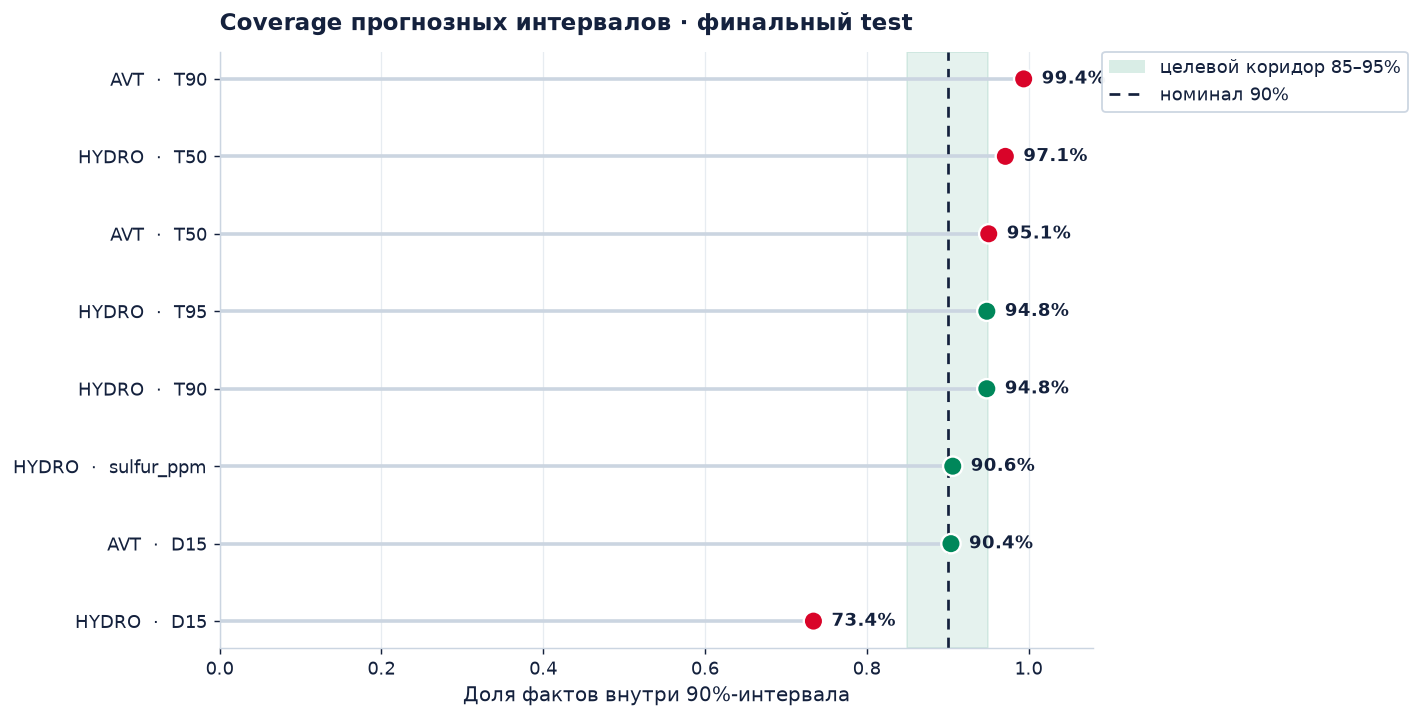

In [20]:
coverage = metrics_table.dropna(subset=["coverage 90%"]).copy()
coverage["label"] = coverage["model"].str.upper() + "  ·  " + coverage["target"]
coverage = coverage.sort_values("coverage 90%").reset_index(drop=True)
coverage["in_target"] = coverage["coverage 90%"].between(0.85, 0.95)
point_colors = coverage["in_target"].map({True: PALETTE["green"], False: PALETTE["red"]})

fig, ax = plt.subplots(figsize=(12, 6.2))
ax.axvspan(0.85, 0.95, color=PALETTE["green"], alpha=0.10, zorder=0)
ax.axvline(0.90, color=PALETTE["ink"], linewidth=1.5, linestyle=(0, (4, 3)), zorder=1)
y = np.arange(len(coverage))
ax.hlines(y, 0.0, coverage["coverage 90%"], color=PALETTE["grid"], linewidth=2.0, zorder=1)
ax.scatter(coverage["coverage 90%"], y, s=115, c=point_colors, edgecolor="white", linewidth=1.3, zorder=3)
for row_y, value in zip(y, coverage["coverage 90%"]):
    ax.annotate(f"{value:.1%}", (value, row_y), xytext=(10, 0), textcoords="offset points", va="center", fontweight="bold", color=PALETTE["ink"])
ax.set_yticks(y, coverage["label"])
ax.set_xlim(0.0, 1.08)
ax.set_xlabel("Доля фактов внутри 90%-интервала")
ax.set_title("Coverage прогнозных интервалов · финальный test", loc="left")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
legend_items = [
    Patch(facecolor=PALETTE["green"], alpha=0.15, label="целевой коридор 85–95%"),
    plt.Line2D([0], [0], color=PALETTE["ink"], linestyle=(0, (4, 3)), label="номинал 90%"),
]
ax.legend(handles=legend_items, loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)
fig.subplots_adjust(left=0.20, right=0.76, top=0.88, bottom=0.14)
plt.show()

## Прогноз против факта

Прогнозы пересчитываются из сохранённых моделей. Полоса — 90%-интервал: фиксированный на validation для обычных показателей, причинно адаптируемый по прошлым ПАК для серы. Это не оценка причинного эффекта действий. Линия — центральный прогноз, точки — факт. Лимит серы — 10 мг/кг.

In [21]:
observations = {
    (stage, target): prediction_observations(model, periods["test"], target, config)
    for stage, model, configs in (
        ("AVT", quality_avt, AVT_TARGET_CONFIG),
        ("Hydro", quality_hydro, HYDRO_TARGET_CONFIG),
    )
    for target, config in configs.items()
}
display(pd.DataFrame([
    {"stage": stage, "target": target, "test observations": len(frame)}
    for (stage, target), frame in observations.items()
]))
# low/high здесь совпадают с рабочим predict: никакой калибровки по test.


,stage,target,test observations
0,AVT,T50,244
1,AVT,T90,167
2,AVT,D15,73
3,AVT,CFPP,43
4,Hydro,T95,388
5,Hydro,cetane_number,13
6,Hydro,sulfur_ppm,57889
7,Hydro,T50,349
8,Hydro,T90,349
9,Hydro,D15,173


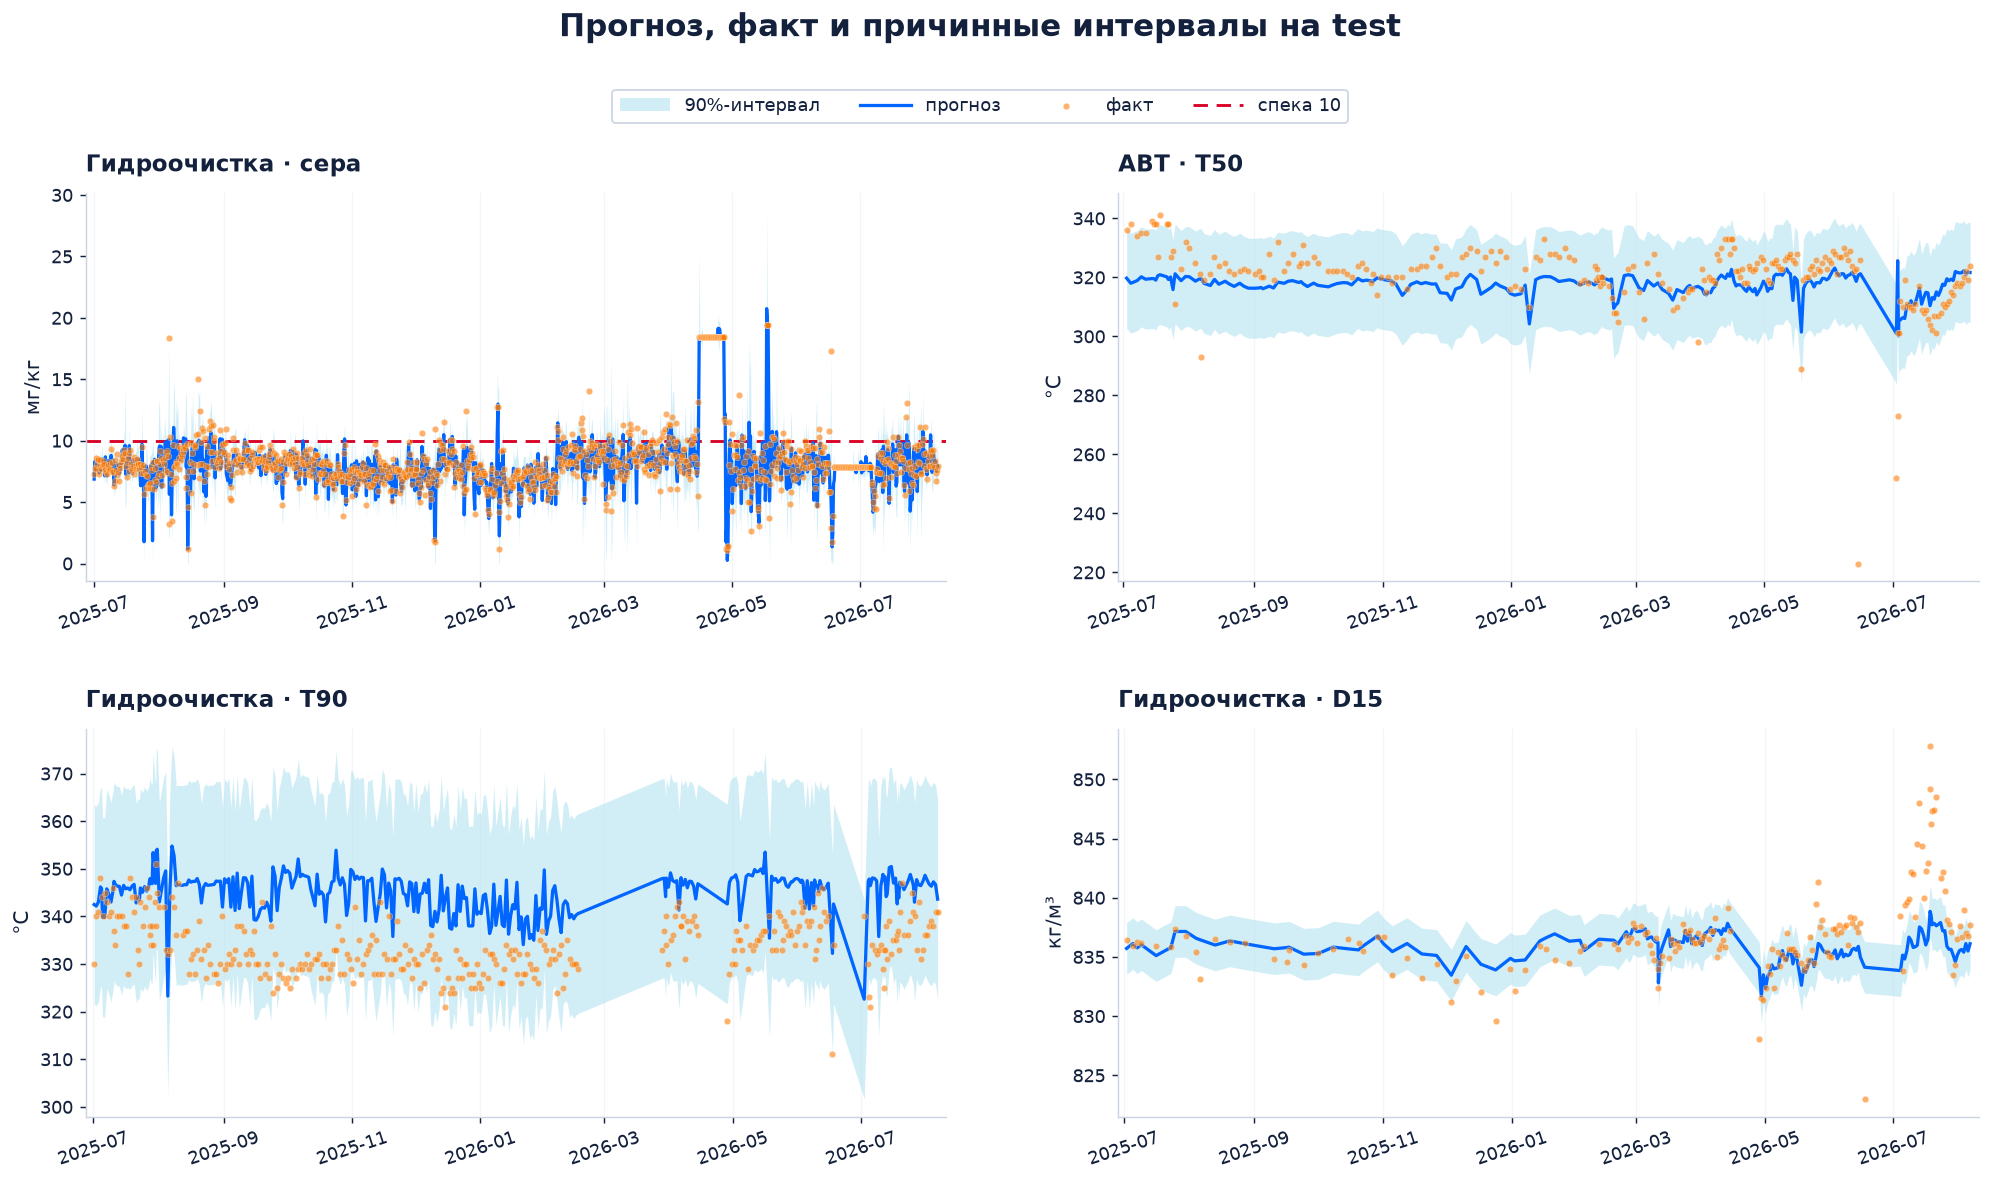

In [22]:
def plot_prediction(ax, data: pd.DataFrame, title: str, unit: str, *, spec_limit: float | None = None) -> None:
    if data.empty:
        ax.text(0.5, 0.5, "Недостаточно test-меток", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return
    shown = data.iloc[np.linspace(0, len(data) - 1, min(1200, len(data)), dtype=int)]
    dates = pd.to_datetime(shown["date"])
    ax.fill_between(dates, shown["low"], shown["high"], color=PALETTE["cyan"], alpha=0.18, linewidth=0, label="90%-интервал")
    ax.plot(dates, shown["prediction"], color=PALETTE["blue"], linewidth=1.8, label="прогноз", zorder=3)
    ax.scatter(dates, shown["actual"], color=PALETTE["orange"], s=13, alpha=0.58, edgecolor="white", linewidth=0.25, label="факт", rasterized=True, zorder=4)
    if spec_limit is not None:
        ax.axhline(spec_limit, color=PALETTE["red"], linestyle=(0, (5, 3)), linewidth=1.6, label=f"спека {spec_limit:g}", zorder=2)
    ax.set_title(title, loc="left")
    ax.set_ylabel(unit)
    ax.margins(x=0.01)
    ax.grid(axis="x", alpha=0.22)
    ax.tick_params(axis="x", labelrotation=18)


fig, axes = plt.subplots(2, 2, figsize=(16, 9.6))
plot_prediction(axes[0, 0], observations[("Hydro", "sulfur_ppm")], "Гидроочистка · сера", "мг/кг", spec_limit=10.0)
plot_prediction(axes[0, 1], observations[("AVT", "T50")], "АВТ · T50", "°C")
plot_prediction(axes[1, 0], observations[("Hydro", "T90")], "Гидроочистка · T90", "°C")
plot_prediction(axes[1, 1], observations[("Hydro", "D15")], "Гидроочистка · D15", "кг/м³")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncol=len(labels), columnspacing=2.2, handlelength=2.8)
fig.suptitle("Прогноз, факт и причинные интервалы на test", fontsize=17, fontweight="bold", y=0.985)
fig.subplots_adjust(left=0.07, right=0.98, top=0.84, bottom=0.10, hspace=0.38, wspace=0.20)
plt.show()

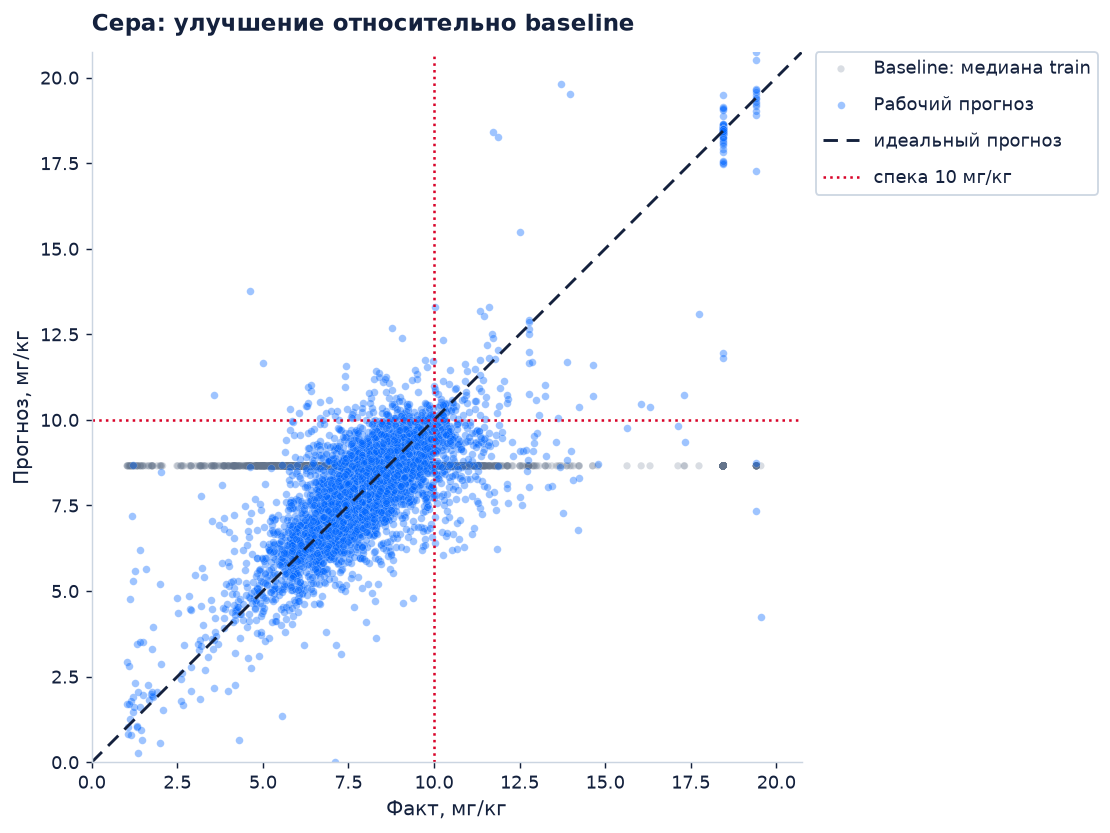

In [23]:
sulfur = observations[("Hydro", "sulfur_ppm")]
finite = sulfur[["actual", "prediction", "baseline"]].dropna()
if finite.empty:
    print("Нет test-наблюдений серы для parity-графика")
else:
    sample = finite.iloc[np.linspace(0, len(finite) - 1, min(6000, len(finite)), dtype=int)]
    lower = float(np.nanmin(sample[["actual", "prediction", "baseline"]].to_numpy()))
    upper = max(float(np.nanmax(sample[["actual", "prediction", "baseline"]].to_numpy())), 10.0, lower + 1.0)
    
    fig, ax = plt.subplots(figsize=(10.5, 7))
    ax.scatter(sample["actual"], sample["baseline"], s=16, alpha=0.24, color=PALETTE["gray"], edgecolor="none", label="Baseline: медиана train", rasterized=True)
    ax.scatter(sample["actual"], sample["prediction"], s=18, alpha=0.38, color=PALETTE["blue"], edgecolor="white", linewidth=0.2, label="Рабочий прогноз", rasterized=True)
    ax.plot([lower, upper], [lower, upper], color=PALETTE["ink"], linewidth=1.6, linestyle=(0, (5, 3)), label="идеальный прогноз")
    ax.axvline(10, color=PALETTE["red"], linewidth=1.4, linestyle=":")
    ax.axhline(10, color=PALETTE["red"], linewidth=1.4, linestyle=":", label="спека 10 мг/кг")
    ax.set(xlim=(lower, upper), ylim=(lower, upper), xlabel="Факт, мг/кг", ylabel="Прогноз, мг/кг")
    ax.set_title("Сера: улучшение относительно baseline", loc="left")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0, labelspacing=1.0)
    fig.subplots_adjust(left=0.10, right=0.72, top=0.90, bottom=0.12)
    plt.show()

## SHAP и реальный срез для демо

Выбирается реальная test-точка с заполненными управляющими тегами; это иллюстрация, не репрезентативная оценка качества. SHAP описывает статистическую связь, не причинный эффект. Если residual ML отключён, отсутствие SHAP объясняется явно.


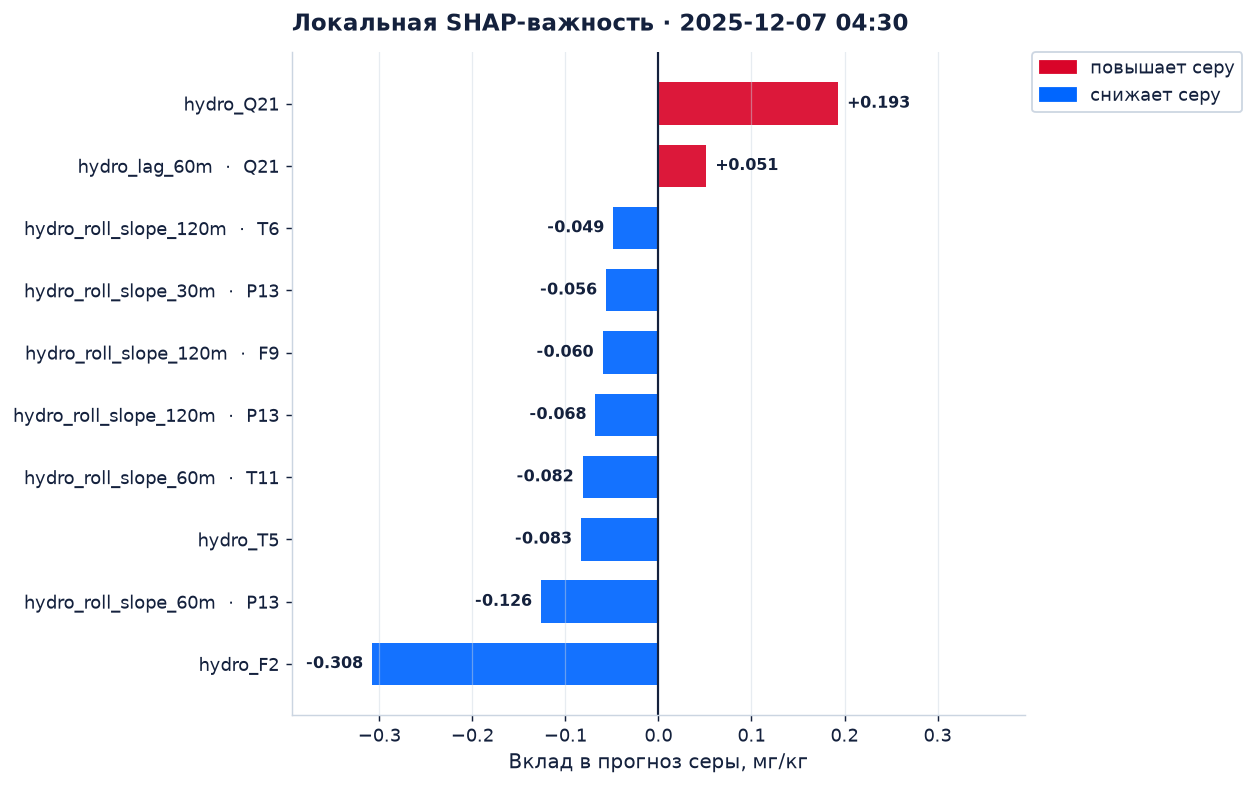

**Demo-точка:** `2025-12-07 04:30`  
**Сера:** 6.00 мг/кг (90% ДИ 4.98–7.02)  
**Риск > 10 мг/кг:** 0.0%  
**Уверенность:** `low`

In [24]:
sulfur_candidates = sulfur.loc[
    sulfur["high"].le(9.0)
].copy()
if sulfur_candidates.empty:
    sulfur_candidates = sulfur.nsmallest(min(100, len(sulfur)), "high")

sulfur_candidates["distance_to_demo"] = (sulfur_candidates["prediction"] - 6.0).abs()
demo_row = None
for candidate in sulfur_candidates.sort_values("distance_to_demo").itertuples():
    proposed = periods["test"].iloc[[int(candidate.source_position)]].copy()
    if proposed[demo_control_tags].apply(pd.to_numeric, errors="coerce").notna().all(axis=None):
        demo_row = inference_frame(proposed).reset_index(drop=True)
        break
if demo_row is None:
    raise RuntimeError("Не найдена test-точка с заполненными управляемыми тегами")

# Прогрев реальной прошлой историей для serving-калибровки; без будущих строк.
if quality_hydro.artifact.get("sulfur_online"):
    position = int(candidate.source_position)
    history_rows = inference_frame(periods["test"].iloc[max(0, position - 90):position])
    for i in range(len(history_rows)):
        quality_hydro.predict(history_rows.iloc[[i]])
demo_prediction = quality_hydro.predict(demo_row)
explanation = quality_hydro.explain(demo_row)
shap_table = pd.DataFrame(explanation.top_features, columns=["feature", "SHAP"])
shap_table = shap_table.sort_values("SHAP")

if shap_table.empty:
    print("Residual ML отключён или SHAP недоступен; вымышленные вклады не строятся.")
else:
    colors = np.where(shap_table["SHAP"] >= 0, PALETTE["red"], PALETTE["blue"])
    feature_labels = [name.replace("__", "  ·  ") for name in shap_table["feature"]]
    fig, ax = plt.subplots(figsize=(12, 6.8))
    bars = ax.barh(feature_labels, shap_table["SHAP"], color=colors, height=0.68, alpha=0.92)
    ax.axvline(0, color=PALETTE["ink"], linewidth=1.2)
    max_abs_shap = max(float(shap_table["SHAP"].abs().max()), 1e-9)
    for bar, value in zip(bars, shap_table["SHAP"]):
        offset = 5 if value >= 0 else -5
        ax.annotate(f"{value:+.3f}", (value, bar.get_y() + bar.get_height() / 2), xytext=(offset, 0), textcoords="offset points", va="center", ha="left" if value >= 0 else "right", fontsize=9, fontweight="bold")
    ax.set_xlim(-1.28 * max_abs_shap, 1.28 * max_abs_shap)
    ax.set_xlabel("Вклад в прогноз серы, мг/кг")
    ax.set_title(f"Локальная SHAP-важность · {demo_row.iloc[0]['date']:%Y-%m-%d %H:%M}", loc="left")
    ax.grid(axis="x"); ax.grid(axis="y", visible=False)
    ax.legend(handles=[Patch(color=PALETTE["red"], label="повышает серу"), Patch(color=PALETTE["blue"], label="снижает серу")], loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)
    fig.subplots_adjust(left=0.32, right=0.79, top=0.89, bottom=0.14)
    plt.show()
    
    
interval = demo_prediction.predictions["sulfur_ppm"]
display(Markdown(
    f"**Demo-точка:** `{demo_row.iloc[0]['date']:%Y-%m-%d %H:%M}`  \n"
    f"**Сера:** {interval.mean:.2f} мг/кг (90% ДИ {interval.low:.2f}–{interval.high:.2f})  \n"
    f"**Риск > 10 мг/кг:** {demo_prediction.spec_risk['sulfur_over_10']:.1%}  \n"
    f"**Уверенность:** `{demo_prediction.confidence}`"
))

## Парето-ранжированные действия: базовые четыре цели

Управление Hydro: T6/F9/P13, границы только из реестра. Минимизируются сера, энергия и суровость, максимизируется прокси выхода. В двумерной проекции доминирование не видно полностью; выдача может включать следующие Парето-слои. При управлении только Hydro прокси выхода АВТ может не меняться.

Действия задаются **абсолютными значениями**. Допустимость проверяется по интервалам качества, диапазонам тегов и совместному историческому облаку. Недопустимые варианты не выдаются за рекомендации. Меньше десяти допустимых за пять секунд — критерий ТЗ не пройден на этой точке.


In [25]:
optimizer = ParetoOptimizer(
    quality_avt=quality_avt,
    quality_hydro=quality_hydro,
    blending=BlendingModel(),
)
constraints = optimizer.constraints_from_registry(
    hard={"sulfur_ppm": (0.0, 10.0), "T95": (0.0, 360.0), "cetane_number": (51.0, 100.0)},
    max_deviation_pct=3.0,
    tags=demo_control_tags,
)

started = time.perf_counter()
variants = optimizer.find_pareto(demo_row, constraints, n_variants=10)
pareto_seconds = time.perf_counter() - started

pareto_rows = []
for rank, variant in enumerate(variants, start=1):
    pareto_rows.append({
        "rank": rank,
        **variant.action,
        **variant.metrics,
        "sulfur_high": variant.expected.predictions["sulfur_ppm"].high,
        "feasible": variant.feasible,
        "reason": variant.infeasible_reason,
    })
pareto_table = pd.DataFrame(pareto_rows, columns=list(dict.fromkeys(["rank", *demo_control_tags, "sulfur", "yield", "energy", "severity", "sulfur_high", "feasible", "reason", *[key for row in pareto_rows for key in row]])))

display(
    pareto_table.style.format({
        **{tag: "{:.2f}" for tag in demo_control_tags},
        "sulfur": "{:.2f}",
        "sulfur_high": "{:.2f}",
        "yield": "{:.3f}",
        "energy": "{:.3f}",
        "severity": "{:.3f}",
    }).background_gradient(subset=["sulfur", "energy", "severity"], cmap="RdYlGn_r")
)
print(f"Оптимизатор вернул {len(variants)} вариантов за {pareto_seconds:.2f} с; допустимых: {sum(v.feasible for v in variants)}")
print("10 допустимых за <5 с:", sum(v.feasible for v in variants) >= 10 and pareto_seconds < 5)


/Users/pavelatrusev/projects/neftecode/.venv/lib/python3.12/site-packages/optuna/_experimental.py:30: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/Users/pavelatrusev/projects/neftecode/.venv/lib/python3.12/site-packages/optuna/_experimental.py:30: ExperimentalWarning: Argument ``constraints_func`` is an experimental feature. The interface can change in the future.
  warnings.warn(


,rank,hydro_T6,hydro_F9,hydro_P13,sulfur,yield,energy,severity,sulfur_high,feasible,reason
0,1,370.78,228.20,3.84,6.03,0.247,0.028,0.369,7.06,False,hard_constraint:T95_above_360
1,2,378.38,216.00,3.94,5.97,0.247,0.371,0.340,6.99,False,hard_constraint:T95_above_360
2,3,372.39,216.19,4.01,5.97,0.247,0.101,0.322,6.99,False,hard_constraint:T95_above_360
3,4,378.13,224.22,4.03,6.01,0.247,0.360,0.346,7.04,False,hard_constraint:T95_above_360
4,5,372.40,226.96,3.88,6.02,0.247,0.102,0.267,7.05,False,hard_constraint:T95_above_360
5,6,373.77,216.77,4.03,5.97,0.247,0.163,0.360,6.99,False,hard_constraint:T95_above_360
6,7,372.63,221.17,3.88,6.00,0.247,0.112,0.162,7.02,False,hard_constraint:T95_above_360
7,8,372.51,223.14,3.95,6.00,0.247,0.107,0.082,7.03,False,hard_constraint:T95_above_360
8,9,373.11,216.93,3.82,5.98,0.247,0.133,0.379,7.00,False,hard_constraint:T95_above_360
9,10,379.04,222.50,3.94,6.00,0.247,0.401,0.233,7.03,False,hard_constraint:T95_above_360


Оптимизатор вернул 10 вариантов за 4.03 с; допустимых: 0
10 допустимых за <5 с: False


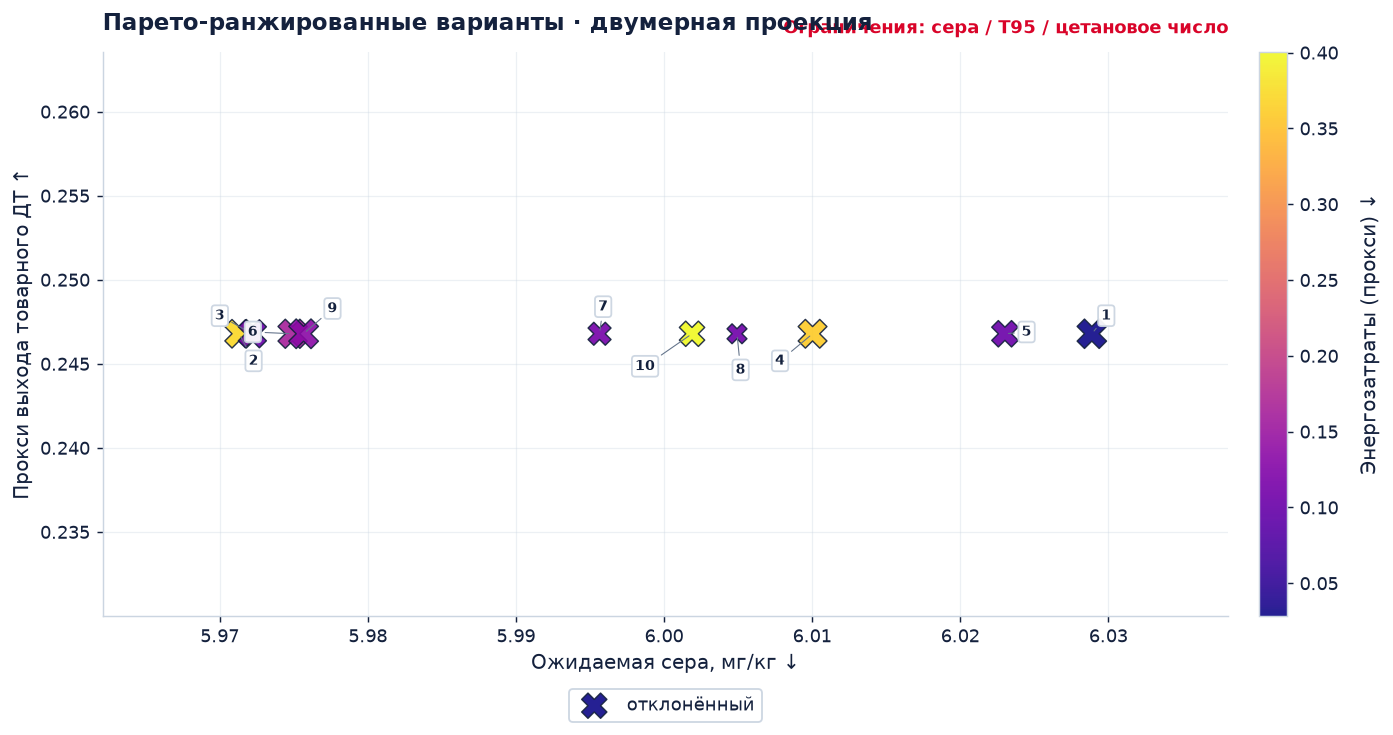

In [26]:
if pareto_table.empty:
    print("Оптимизатор не вернул вариантов; график пуст.")
else:
    fig, ax = plt.subplots(figsize=(12, 7))
    feasible_mask = pareto_table["feasible"].astype(bool)
    energy_min = float(pareto_table["energy"].min())
    energy_max = float(pareto_table["energy"].max())
    energy_norm = Normalize(vmin=energy_min, vmax=max(energy_max, energy_min + 1e-9))
    annotation_offsets = [(8, 10), (8, -15), (-18, 10), (-18, -15), (12, 1), (-22, 1), (2, 15), (2, -20), (16, 14), (-26, -18)]
    points = None
    for mask, marker, label in [
        (feasible_mask, "o", "допустимый"),
        (~feasible_mask, "X", "отклонённый"),
    ]:
        subset = pareto_table.loc[mask]
        if subset.empty:
            continue
        sizes = 80 + 500 * subset["severity"].clip(lower=0)
        points = ax.scatter(
            subset["sulfur"], subset["yield"], c=subset["energy"], s=sizes,
            cmap="plasma", norm=energy_norm, marker=marker, alpha=0.90, edgecolor=PALETTE["ink"], linewidth=0.8, label=label, zorder=3,
        )
        for _, row in subset.iterrows():
            offset = annotation_offsets[(int(row["rank"]) - 1) % len(annotation_offsets)]
            ax.annotate(str(int(row["rank"])), (row["sulfur"], row["yield"]), xytext=offset, textcoords="offset points", fontsize=8, fontweight="bold", ha="center", va="center", bbox={"boxstyle": "round,pad=0.22", "fc": "white", "ec": PALETTE["grid"], "alpha": 0.94}, arrowprops={"arrowstyle": "-", "color": PALETTE["gray"], "lw": 0.6})
    
    ax.set_xlabel("Ожидаемая сера, мг/кг ↓")
    ax.set_ylabel("Прокси выхода товарного ДТ ↑")
    ax.set_title("Парето-ранжированные варианты · двумерная проекция", loc="left")
    ax.text(1.0, 1.025, "Ограничения: сера / T95 / цетановое число", transform=ax.transAxes, ha="right", va="bottom", color=PALETTE["red"], fontweight="bold")
    ax.margins(x=0.16, y=0.18)
    ax.grid(alpha=0.35, zorder=0)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2, borderaxespad=0, columnspacing=2.0)
    if points is not None:
        colorbar = fig.colorbar(points, ax=ax, pad=0.025, fraction=0.05)
        colorbar.set_label("Энергозатраты (прокси) ↓", labelpad=12)
    fig.subplots_adjust(left=0.10, right=0.88, top=0.84, bottom=0.22)
    plt.show()

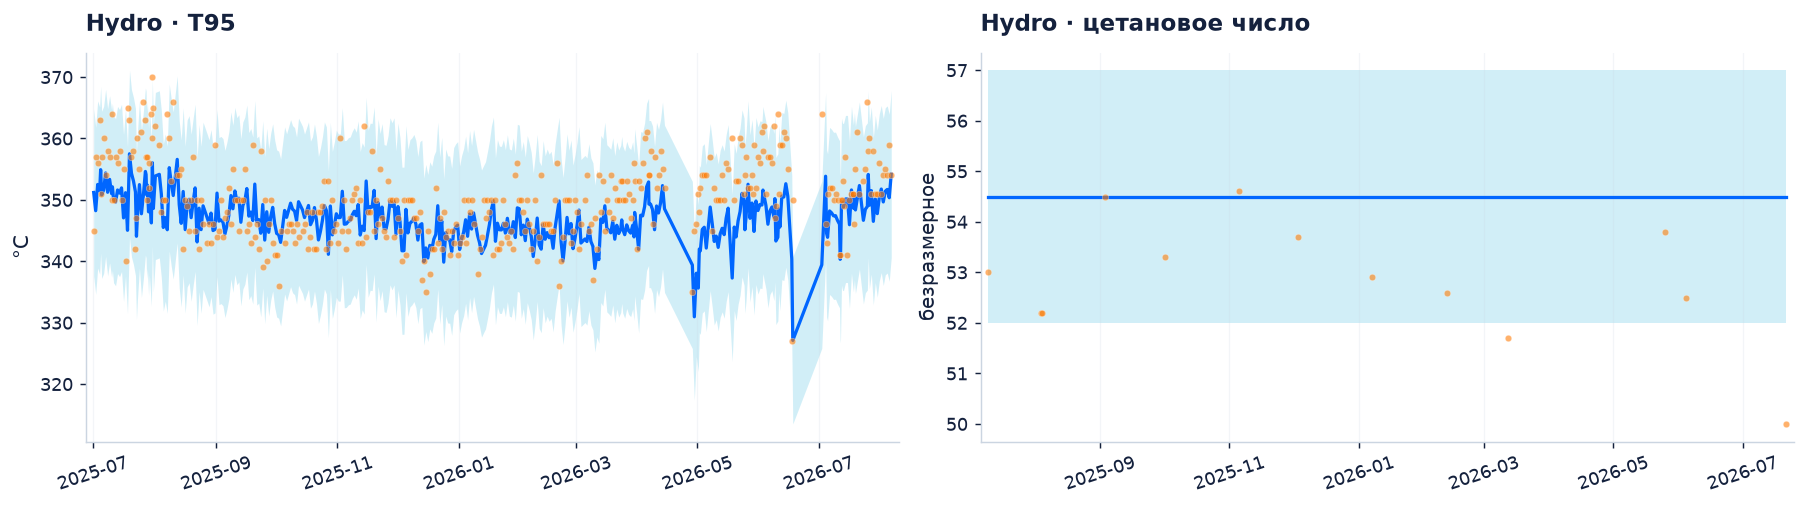

Показанные резервные оценки при малом числе меток не подтверждают точность ML.


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_prediction(axes[0], observations[("Hydro", "T95")], "Hydro · T95", "°C")
plot_prediction(axes[1], observations[("Hydro", "cetane_number")], "Hydro · цетановое число", "безразмерное")
plt.tight_layout()
plt.show()
print("Показанные резервные оценки при малом числе меток не подтверждают точность ML.")


## Физический блендинг и детектор аномалий

Сначала — проверяемый массовый баланс без оптимизации. Сера/T95/цетановое число здесь смешиваются линейно как сценарное приближение. Закон ПТФ в текущем `BlendingModel` — неподтверждённый индекс, не доказанная стандартная формула. AUC детектора без независимой разметки инцидентов не является подтверждённым критерием качества.


In [28]:
scenario_config = default_scenario()
display(pd.DataFrame(scenario_config["tanks"]))
print("Явные сценарные допущения:", {k: v for k, v in scenario_config.items() if k != "tanks"})
components = [Component(name=t["name"], properties=t["properties"], mass_flow=t["mass_flow"])
              for t in scenario_config["tanks"]]
mixture = BlendingModel().blend(components, [0.5, 0.5])
display(pd.DataFrame([{"component": c.name, **c.properties} for c in components]
                     + [{"component": "50/50 смесь", **mixture.properties}]))
print("Расчётная общая масса, т/ч:", mixture.total_mass)
anomaly_path = ARTIFACT_DIR / "anomaly.pkl"
if anomaly_path.exists():
    anomaly_report = AnomalyDetector.load(str(anomaly_path)).score(demo_row)
    display(pd.DataFrame([asdict(anomaly_report)]))
else:
    print("anomaly.pkl отсутствует: комплект артефактов сдачи неполон.")
display(pd.DataFrame([metrics_report.get("anomaly", {})]))


,name,properties,mass_flow
0,low_sulfur_tank,"{'sulfur_ppm': 3.0, 'T95': 330.0, 'cetane_number': 53.0}",40.0
1,economy_tank,"{'sulfur_ppm': 15.0, 'T95': 360.0, 'cetane_number': 47.0}",40.0


Явные сценарные допущения: {'basis': 'synthetic_reservoirs_not_historical_validation', 'hydro_mass_flow': 100.0, 'max_stored_fraction': 0.5, 'max_additive_fraction': 0.03, 'cetane_gain_per_additive_pct': 1.0, 'additive_cost_ratio': 100.0, 'desulfurization_cost_weight': 0.2, 'notes': 'Tank properties, additive efficiency, flow and cost slope are adjustable assumptions. Hard product limits must be supplied by the caller.'}


,component,sulfur_ppm,T95,cetane_number
0,low_sulfur_tank,3.0,330.0,53.0
1,economy_tank,15.0,360.0,47.0
2,50/50 смесь,9.0,345.0,50.0


Расчётная общая масса, т/ч: 80.0


,is_anomaly,anomaly_score,flagged_tags,is_out_of_envelope,stale_tags
0,False,0.109361,[],False,[]


,auc,n_test_rows,n_flagged_in_test,flagged_share,n_isolation_forest,n_out_of_envelope,n_rolling_z_score,n_stale,n_missing,has_incident_labels
0,None,57889,29224,0.504828,2241,17767,1023,16116,0,False


## Три регулируемых ML-сценария

Это не валидация на исторических воздействиях и не end-to-end с оркестратором. Резервуары, цена и эффективность присадки — явные заменяемые допущения. Присадка ≤3% конечной массы, цена в 100 раз выше ДТ; стоимость — пятая цель. При неизвестном эффекте все эти прогнозы имеют низкую уверенность.

Множитель серы — **синтетический стресс** на прогноз выхода Hydro, не измеренная сера сырья АВТ. Горизонт эффекта 0–180 минут отличается от шага рекомендаций 15–60 минут. Отдельный отклик серы — observational surrogate, остальные показатели после действия — статические оценки. Невыполнимые спеки и неопределённые интервалы не скрываются.


In [29]:
# Меняйте эти параметры перед защитой; не переобучайте модели на test.
SCENARIOS = [
    {"name": "Базовый режим", "feed_multiplier": 1.0, "sulfur_limit": 10.0, "horizon": 180.0},
    {"name": "Рост серы (synthetic)", "feed_multiplier": 1.5, "sulfur_limit": 10.0, "horizon": 180.0},
    {"name": "Ужесточение спецификации", "feed_multiplier": 1.0, "sulfur_limit": 7.0, "horizon": 180.0},
]
RECOMMENDATION_STEP_MINUTES = 30
assert 15 <= RECOMMENDATION_STEP_MINUTES <= 60
scenario_results, scenario_summary = {}, []
for params in SCENARIOS:
    state = demo_row.copy()
    state["ml_feed_sulfur_multiplier"] = params["feed_multiplier"]
    state["ml_action_horizon_minutes"] = params["horizon"]
    state["ml_blending_scenario"] = pd.Series([scenario_config], index=state.index)
    limits = optimizer.constraints_from_registry(
        hard={"sulfur_ppm": (0., params["sulfur_limit"]), "T95": (0., 360.),
              "cetane_number": (51., 100.)},
        max_deviation_pct=3., tags=demo_control_tags,
    )
    start = time.perf_counter()
    choices = optimizer.find_pareto(state, limits, n_variants=10)
    duration = time.perf_counter() - start
    scenario_results[params["name"]] = choices
    acceptable = [v for v in choices if v.feasible]
    scenario_summary.append({"scenario": params["name"], "returned": len(choices),
                             "feasible": len(acceptable), "seconds": duration,
                             "10 feasible in <5s": len(acceptable) >= 10 and duration < 5})
    print(params["name"])
    display(pd.DataFrame([{
        "feasible": v.feasible, "reason": v.infeasible_reason,
        **v.action, **v.metrics, "confidence": v.expected.confidence,
        "warnings": "; ".join(v.expected.warnings),
    } for v in choices]))
display(pd.DataFrame(scenario_summary))
# Без записи файлов; NaN/inf превращаются в null для строгого JSON.
print(json.dumps(clean_json([asdict(v) for v in scenario_results[SCENARIOS[0]["name"]][:1]]),
                 ensure_ascii=False, indent=2, allow_nan=False))


/Users/pavelatrusev/projects/neftecode/.venv/lib/python3.12/site-packages/optuna/_experimental.py:30: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/Users/pavelatrusev/projects/neftecode/.venv/lib/python3.12/site-packages/optuna/_experimental.py:30: ExperimentalWarning: Argument ``constraints_func`` is an experimental feature. The interface can change in the future.
  warnings.warn(


Базовый режим


,feasible,reason,hydro_F9,hydro_P13,hydro_T6,blend__stored_fraction,blend__tank_share,blend__additive_fraction,sulfur,yield,energy,severity,cost,additive_fraction,stored_fraction,tank_share,product_mass_flow,confidence,warnings,tank_capacity_violation
0,False,hard_constraint:T95_above_360,224.233908,3.949666,379.774326,0.007791,0.995254,0.029875,5.808227,0.246786,0.433592,0.269611,4.035465,0.029875,0.007791,0.995254,103.888862,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...,NaN
1,False,low_historical_density,224.434848,3.907068,369.366448,0.087675,0.962408,0.015427,5.697336,0.246786,0.000000,0.129101,2.610535,0.015427,0.087675,0.962408,111.327496,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...,NaN
2,False,tank_capacity_violation,222.948926,3.890993,371.471274,0.451714,0.926843,0.002945,6.004027,0.246786,0.059727,0.129373,1000000.000000,NaN,NaN,NaN,NaN,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...,1.0
3,False,low_historical_density,221.172119,3.881574,372.628912,0.069747,0.292145,0.010991,6.309043,0.246786,0.111853,0.162404,2.164598,0.010991,0.069747,0.292145,108.692250,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...,NaN
4,False,tank_capacity_violation,222.551927,3.926190,362.058227,0.365028,0.239529,0.023483,6.002153,0.246786,0.000000,0.212801,1000000.000000,NaN,NaN,NaN,NaN,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...,1.0
5,False,low_historical_density,221.493578,3.989545,363.474955,0.257117,0.592415,0.001394,6.475069,0.246786,0.000000,0.225199,1.218643,0.001394,0.257117,0.592415,134.798582,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...,NaN
6,False,tank_capacity_violation,221.880979,3.964974,378.818188,0.472905,0.043978,0.025343,5.998987,0.246786,0.390540,0.238271,1000000.000000,NaN,NaN,NaN,NaN,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...,1.0
7,False,tank_capacity_violation,225.080736,3.988292,362.751899,0.471429,0.098446,0.008279,6.014101,0.246786,0.000000,0.270064,1000000.000000,NaN,NaN,NaN,NaN,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...,1.0
8,False,low_historical_density,226.255014,3.887186,376.081953,0.005375,0.072885,0.021502,5.932859,0.246786,0.267334,0.270523,3.206186,0.021502,0.005375,0.072885,102.749719,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...,NaN
9,False,tank_capacity_violation,227.701463,3.892418,372.349305,0.484802,0.102676,0.029320,6.026508,0.246786,0.099263,0.275467,1000000.000000,NaN,NaN,NaN,NaN,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...,1.0


/Users/pavelatrusev/projects/neftecode/.venv/lib/python3.12/site-packages/optuna/_experimental.py:30: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/Users/pavelatrusev/projects/neftecode/.venv/lib/python3.12/site-packages/optuna/_experimental.py:30: ExperimentalWarning: Argument ``constraints_func`` is an experimental feature. The interface can change in the future.
  warnings.warn(


Рост серы (synthetic)


...

/Users/pavelatrusev/projects/neftecode/.venv/lib/python3.12/site-packages/optuna/_experimental.py:30: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/Users/pavelatrusev/projects/neftecode/.venv/lib/python3.12/site-packages/optuna/_experimental.py:30: ExperimentalWarning: Argument ``constraints_func`` is an experimental feature. The interface can change in the future.
  warnings.warn(


Ужесточение спецификации


,feasible,reason,hydro_F9,hydro_P13,hydro_T6,blend__stored_fraction,blend__tank_share,blend__additive_fraction,sulfur,yield,energy,severity,cost,additive_fraction,stored_fraction,tank_share,product_mass_flow,confidence,warnings
0,False,hard_constraint:T95_above_360,227.056445,4.032006,378.733697,0.014866,0.346191,0.020455,5.970464,0.246786,0.386736,0.400847,3.102510,0.020455,0.014866,0.346191,103.628811,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...
1,False,hard_constraint:sulfur_ppm_above_7,221.493578,3.989545,363.474955,0.257117,0.592415,0.001394,6.475069,0.246786,0.000000,0.225199,1.218643,0.001394,0.257117,0.592415,134.798582,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...
2,False,hard_constraint:sulfur_ppm_above_7,221.172119,3.881574,372.628912,0.069747,0.292145,0.010991,6.309043,0.246786,0.111853,0.162404,2.164598,0.010991,0.069747,0.292145,108.692250,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...
3,False,hard_constraint:sulfur_ppm_above_7,227.782697,4.021599,361.636768,0.347140,0.585968,0.009126,6.639711,0.246786,0.000000,0.401400,1.983052,0.009126,0.347140,0.585968,154.582756,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...
4,False,hard_constraint:sulfur_ppm_above_7,226.508644,3.864329,363.078556,0.091702,0.304242,0.015743,6.406992,0.246786,0.000000,0.326211,2.633518,0.015743,0.091702,0.304242,111.856987,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...
5,False,hard_constraint:sulfur_ppm_above_7,225.119181,3.912438,364.697003,0.105215,0.069378,0.025991,6.693504,0.246786,0.000000,0.203178,3.643581,0.025991,0.105215,0.069378,114.740889,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...
6,False,hard_constraint:sulfur_ppm_above_7,223.383425,4.019426,361.005764,0.097991,0.045227,0.009760,6.767522,0.246786,0.000000,0.328940,2.038193,0.009760,0.097991,0.045227,111.956376,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...
7,False,hard_constraint:sulfur_ppm_above_7,218.176970,3.828046,362.503915,0.203612,0.326749,0.001258,7.010611,0.246786,0.000000,0.386436,1.197795,0.001258,0.203612,0.326749,125.725071,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...
8,False,hard_constraint:sulfur_ppm_above_7,224.566560,3.829918,359.863367,0.354410,0.414608,0.026679,7.235603,0.246786,0.000000,0.401939,3.711329,0.026679,0.354410,0.414608,159.142875,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...
9,False,hard_constraint:sulfur_ppm_above_7,227.878975,4.024892,372.954593,0.252847,0.343954,0.005935,7.209395,0.246786,0.126517,0.351604,1.658729,0.005935,0.252847,0.343954,134.640512,low,T90: VAK formula is absent; train median is used as baseline; CFPP: LightGBM is unavailable (0 l...


,scenario,returned,feasible,seconds,10 feasible in <5s
0,Базовый режим,10,0,4.025994,False
1,Рост серы (synthetic),10,0,4.017088,False
2,Ужесточение спецификации,10,0,4.025381,False


[
  {
    "action": {
      "hydro_F9": 224.23390777567062,
      "hydro_P13": 3.949665828131139,
      "hydro_T6": 379.77432620581004,
      "blend__stored_fraction": 0.007790900823406721,
      "blend__tank_share": 0.9952537812244289,
      "blend__additive_fraction": 0.029874756899045944
    },
    "expected": {
      "predictions": {
        "sulfur_ppm": {
          "mean": 5.80822657803955,
          "low": 4.821244718286569,
          "high": 6.795208437792532,
          "unit": "ppm"
        },
        "T95": {
          "mean": 347.45016047084687,
          "low": 333.944869493442,
          "high": 360.9554514482517,
          "unit": "C"
        },
        "cetane_number": {
          "mean": 57.47556747475088,
          "low": 54.995044726809404,
          "high": 59.95609022269237,
          "unit": "dimensionless"
        }
      },
      "spec_risk": {
        "sulfur_over_10": 1.4162004902118497e-12
      },
      "confidence": "low",
      "warnings": [
        "T90: V

## Что предъявлять и что ещё проверить

1. Новые три `.pkl` и `metrics_report.json`; версия справочника и задержка ЛИМС указаны в отчёте.
2. Таблицу исторических метрик, включая независимую лабораторию; не объявлять `NOT VERIFIED` успехом.
3. Coverage 85–95%, recall превышений ≥90%, улучшение относительно ВАК там, где ВАК существует. При отсутствии превышений recall не доказан.
4. `predict <100 ms` из runtime-отчёта и фактические число/время допустимых вариантов на демо-точках.
5. Пропуски CFPP и редкое цетановое число, закон смешения ПТФ, управляемость T6/F9/P13, резервуары и эффективность присадки — согласовать с экспертом.
6. Совместный end-to-end прогон с оркестратором выполняется отдельно: этот ноутбук проверяет только ML.

Подробный статус требований и последовательность запуска: `docs/ml_compliance.md`. Все результаты выше вычисляются при запуске; сохранённых графиков от старых моделей нет.


In [30]:
display(pd.DataFrame(metrics_report.get("runtime", {})).T)
print("Нет измерения — нет подтверждения порога 100 ms. Среднее и p95 различайте.")
print("Сценарии не подтверждают причинный эффект действий и не заменяют финальный test.")


,median_ms,p95_ms,max_ms
quality_avt,28.880646,45.412825,52.051292
quality_hydro,25.854250,42.088918,43.197500


Нет измерения — нет подтверждения порога 100 ms. Среднее и p95 различайте.
Сценарии не подтверждают причинный эффект действий и не заменяют финальный test.
